In [5]:
import pickle
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [6]:
from batchdetect.loader import *
from batchdetect.mixture import HeavyMixture,parametric_bootstrap_lrt

In [7]:
df_thal_likelihoods = pd.read_csv('likelihoods_essential.csv')
snames = df_thal_likelihoods['Sample Name'].values
likelihoods = df_thal_likelihoods['Likelihood'].values
y_hat = df_thal_likelihoods['Label'].values

In [8]:
counts_thal,y_thal,sample_id,features,_ = load_essential_ffpe()
counts_thal = counts_thal[:-1]
y_thal = y_thal[:-1]
sample_id = sample_id[:-1]

In [9]:
index_homozygous_del = []
counts_thal_new = np.delete(counts_thal, index_homozygous_del, axis=0)
likelihoods_ess = np.delete(likelihoods, index_homozygous_del)
y_ess = np.delete(y_hat, index_homozygous_del)
snames_ess = np.delete(snames,index_homozygous_del)

In [11]:
df_thal_likelihoods = pd.read_csv('likelihoods_br283.csv')
snames = df_thal_likelihoods['Sample Name'].values
likelihoods = df_thal_likelihoods['Likelihood'].values
y_hat = df_thal_likelihoods['Label'].values

counts_thal,y_thal,sample_id,features,_ = load_br283_cross_lot_covs()
counts_thal = counts_thal[:-1]
y_thal = y_thal[:-1]
sample_id = sample_id[:-1]

index_homozygous_del = [12,13,14]
counts_thal_new = np.delete(counts_thal, index_homozygous_del, axis=0)
likelihoods_br283 = np.delete(likelihoods, index_homozygous_del)
y_br283 = np.delete(y_hat, index_homozygous_del)
snames_br283 = np.delete(snames,index_homozygous_del)

In [13]:
df_thal_likelihoods = pd.read_csv('likelihoods_thal131.csv')
print(df_thal_likelihoods.head())
snames = df_thal_likelihoods['Sample Name'].values
likelihoods = df_thal_likelihoods['Likelihood'].values
y_hat = df_thal_likelihoods['Label'].values

counts_thal,y_thal,sample_id,features,_ = load_thal_cross_lot_covs()
counts_thal = counts_thal[:-1]
y_thal = y_thal[:-1]
sample_id = sample_id[:-1]

index_homozygous_del = [4,5,11,18,19,24,32,36,57]
counts_thal_new = np.delete(counts_thal, index_homozygous_del, axis=0)
likelihoods_thal = np.delete(likelihoods, index_homozygous_del)
y_thal = np.delete(y_hat, index_homozygous_del)
snames_thal = np.delete(snames,index_homozygous_del)

                      Sample Name  Likelihood  Label
0     RDvGMpTHALD2d200302iM1-PB05   39.361303      0
1     RDvGMpTHALD2d200302iM1-PB06   39.298358      0
2     RDvGMpTHALD2d200302iM1-PB07   66.229424      0
3      RDvGMpTHALD2d200302iM1-TV2   38.732541      0
4  RDvGMpTHALD2d200302iM1-aTHAL31 -214.132134      0


In [16]:
import seaborn as sns

ModuleNotFoundError: No module named 'seaborn'

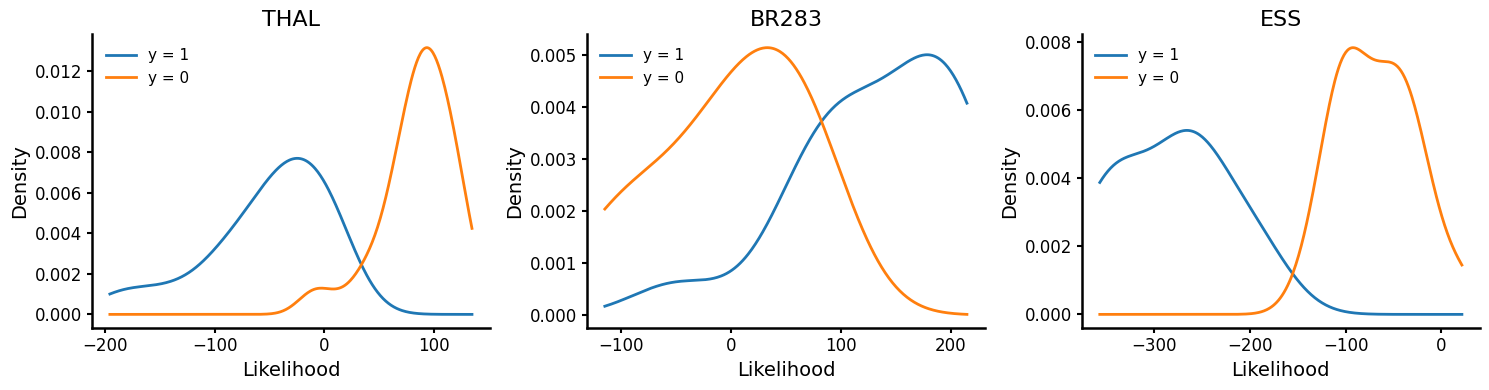

In [17]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

datasets = [
    (likelihoods_thal, y_thal, "THAL"),
    (likelihoods_br283, y_br283, "BR283"),
    (likelihoods_ess, y_ess, "ESS"),
]

for ax, (likelihoods, y, title) in zip(axes, datasets):
    pos = np.asarray(likelihoods)[np.asarray(y) == 1]
    neg = np.asarray(likelihoods)[np.asarray(y) == 0]

    xmin = np.min(likelihoods)
    xmax = np.max(likelihoods)
    xgrid = np.linspace(xmin, xmax, 400)

    kde_pos = gaussian_kde(pos)
    kde_neg = gaussian_kde(neg)

    ax.plot(xgrid, kde_pos(xgrid), label="y = 1", linewidth=2)
    ax.plot(xgrid, kde_neg(xgrid), label="y = 0", linewidth=2)

    ax.set_title(title, fontsize=16)
    ax.set_xlabel("Likelihood", fontsize=14)
    ax.set_ylabel("Density", fontsize=14)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["bottom"].set_linewidth(1.8)
    ax.spines["left"].set_linewidth(1.8)
    ax.tick_params(axis="both", labelsize=12, width=1.5)
    ax.legend(frameon=False, fontsize=11)

plt.tight_layout()
plt.show()

In [23]:
likelihoods_thal = likelihoods_thal/120
likelihoods_br283 = likelihoods_br283/283
likelihoods_ess = likelihoods_ess/172

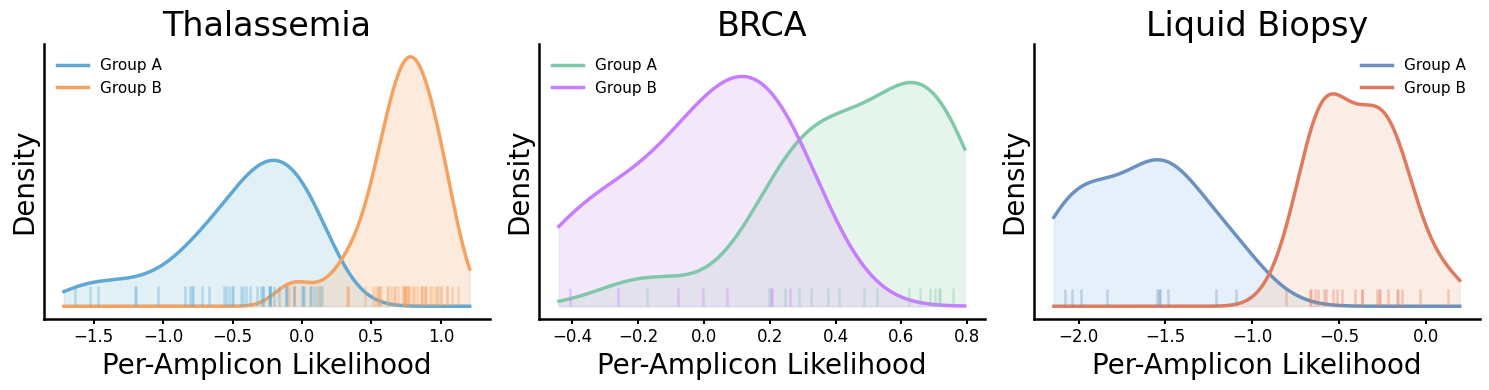

In [26]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)

datasets = [
    (likelihoods_thal, y_thal, "Thalassemia"),
    (likelihoods_br283, y_br283, "BRCA"),
    (likelihoods_ess, y_ess, "Liquid Biopsy"),
]

# soft pastel pairs: (y=1 line/fill, y=0 line/fill)
color_pairs = [
    ("#5FA8D3", "#A9D6E5", "#F4A261", "#F7C59F"),
    ("#7FC8A9", "#B7E4C7", "#C77DFF", "#DDBDF1"),
    ("#6C91BF", "#B9D6F2", "#E07A5F", "#F2CCB6"),
]

for ax, (likelihoods, y, title), colors in zip(axes, datasets, color_pairs):
    likelihoods = np.asarray(likelihoods)
    y = np.asarray(y)

    pos = likelihoods[y == 1]
    neg = likelihoods[y == 0]

    xmin = np.min(likelihoods)
    xmax = np.max(likelihoods)
    xrng = xmax - xmin
    xgrid = np.linspace(xmin - 0.03 * xrng, xmax + 0.03 * xrng, 500)

    kde_pos = gaussian_kde(pos)
    kde_neg = gaussian_kde(neg)

    y_pos = kde_pos(xgrid)
    y_neg = kde_neg(xgrid)

    pos_line, pos_fill, neg_line, neg_fill = colors

    # KDE lines + light fill
    ax.plot(xgrid, y_pos, color=pos_line, linewidth=2.5, label="Group A")
    ax.fill_between(xgrid, 0, y_pos, color=pos_fill, alpha=0.35)

    ax.plot(xgrid, y_neg, color=neg_line, linewidth=2.5, label="Group B")
    ax.fill_between(xgrid, 0, y_neg, color=neg_fill, alpha=0.35)

    # rug plots
    rug_height = 0.08 * max(y_pos.max(), y_neg.max())
    lwv = 1.8
    ax.vlines(pos, 0, rug_height, color=pos_line, alpha=0.35, linewidth=lwv)
    ax.vlines(neg, 0, rug_height, color=neg_line, alpha=0.35, linewidth=lwv)

    ax.set_title(title, fontsize=24)
    ax.set_xlabel("Per-Amplicon Likelihood", fontsize=20)

    # remove y-axis numbers
    ax.set_yticks([])
    ax.set_ylabel("Density", fontsize=20)

    # styling
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["bottom"].set_linewidth(1.8)
    ax.spines["left"].set_linewidth(1.8)
    ax.tick_params(axis="x", labelsize=12, width=1.5)
    ax.tick_params(axis="y", length=0)
    ax.legend(frameon=False, fontsize=11)

plt.tight_layout()
plt.savefig("Results_2.pdf")
plt.show()